### 1. Imports e carregamento

In [1]:
import pandas as pd

In [5]:
df = pd.read_csv('/content/churn.csv')
df.head()

,Unnamed: 0,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,7590-VHVEG,Female,No,Yes,No,1,No,No phone service,DSL,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,Stayed
1,1,5575-GNVDE,Male,No,No,No,34,Yes,No,DSL,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,Stayed
2,2,3668-QPYBK,Male,No,No,No,2,Yes,No,DSL,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Churned
3,3,7795-CFOCW,Male,No,No,No,45,No,No phone service,DSL,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,Stayed
4,4,9237-HQITU,Female,No,No,No,2,Yes,No,Fiber optic,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Churned


### 2. Visão geral da base

In [6]:
df.shape

(7043, 22)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        7043 non-null   int64  
 1   customerID        7043 non-null   object 
 2   gender            7043 non-null   object 
 3   SeniorCitizen     7043 non-null   object 
 4   Partner           7043 non-null   object 
 5   Dependents        7043 non-null   object 
 6   tenure            7043 non-null   int64  
 7   PhoneService      7043 non-null   object 
 8   MultipleLines     7043 non-null   object 
 9   InternetService   7043 non-null   object 
 10  OnlineSecurity    7043 non-null   object 
 11  OnlineBackup      7043 non-null   object 
 12  DeviceProtection  7043 non-null   object 
 13  TechSupport       7043 non-null   object 
 14  StreamingTV       7043 non-null   object 
 15  StreamingMovies   7043 non-null   object 
 16  Contract          7043 non-null   object 


In [8]:
df.describe()

,Unnamed: 0,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,3521.000000,32.371149,64.761692
std,2033.283305,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,1760.500000,9.000000,35.500000
50%,3521.000000,29.000000,70.350000
75%,5281.500000,55.000000,89.850000
max,7042.000000,72.000000,118.750000


### 3. Verificar valores nulos

In [9]:
df.isnull().sum().sort_values(ascending=False)

,0
Unnamed: 0,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0


### 4. Verificar duplicados

In [10]:
df.duplicated().sum()

np.int64(0)

### 5. Distribuição do churn

In [11]:
df['Churn'].value_counts()

,count
Churn,
Stayed,5174
Churned,1869


In [12]:
df['Churn'].value_counts(normalize=True)

,proportion
Churn,
Stayed,0.73463
Churned,0.26537


### 6. Visual simples

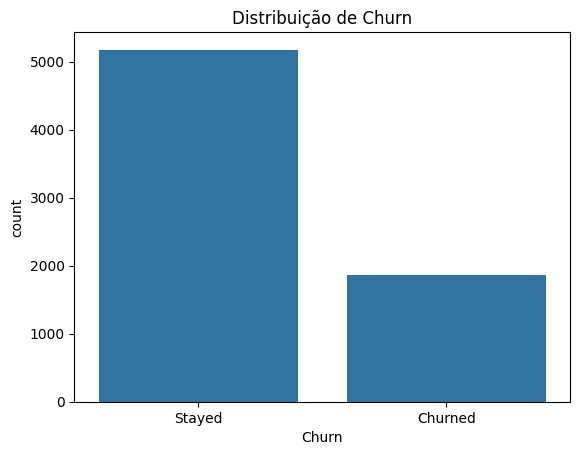

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Churn', data=df)
plt.title('Distribuição de Churn')
plt.show()

### 7. Tratamento da base para o modelo de ML

In [17]:
import pandas as pd


def preprocess_data(df):

    # =========================
    # 1. Remover colunas inúteis
    # =========================
    drop_cols = ['customerID', 'Unnamed: 0']
    df = df.drop(columns=[col for col in drop_cols if col in df.columns])

    # =========================
    # 2. Converter variável alvo
    # =========================
    df['Churn'] = df['Churn'].map({'Churned': 1, 'Stayed': 0})

    # =========================
    # 3. Corrigir coluna numérica
    # =========================
    if 'TotalCharges' in df.columns:
        df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
        df['TotalCharges'] = df['TotalCharges'].fillna(0)

    # =========================
    # 4. Converter Yes/No para 1/0 (otimiza modelo)
    # =========================
    binary_map = {'Yes': 1, 'No': 0}

    for col in df.columns:
        if df[col].dtype == 'object':
            if set(df[col].unique()).issubset(set(['Yes', 'No'])):
                df[col] = df[col].map(binary_map)

    # =========================
    # 5. Encoding categórico
    # =========================
    categorical_cols = df.select_dtypes(include=['object']).columns

    df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

    df = df.astype(int)

    return df

In [18]:
df_processed = preprocess_data(df)

df_processed.head()

,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,gender_Male,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,0,1,0,1,29,29,0,0,...,0,0,0,0,0,0,0,0,1,0
1,0,0,0,34,1,0,56,1889,0,1,...,0,0,0,0,0,1,0,0,0,1
2,0,0,0,2,1,1,53,108,1,1,...,0,0,0,0,0,0,0,0,0,1
3,0,0,0,45,0,0,42,1840,0,1,...,1,0,0,0,0,1,0,0,0,0
4,0,0,0,2,1,1,70,151,1,0,...,0,0,0,0,0,0,0,0,1,0


In [19]:
df_processed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 32 columns):
 #   Column                                 Non-Null Count  Dtype
---  ------                                 --------------  -----
 0   SeniorCitizen                          7043 non-null   int64
 1   Partner                                7043 non-null   int64
 2   Dependents                             7043 non-null   int64
 3   tenure                                 7043 non-null   int64
 4   PhoneService                           7043 non-null   int64
 5   PaperlessBilling                       7043 non-null   int64
 6   MonthlyCharges                         7043 non-null   int64
 7   TotalCharges                           7043 non-null   int64
 8   Churn                                  7043 non-null   int64
 9   gender_Male                            7043 non-null   int64
 10  MultipleLines_No phone service         7043 non-null   int64
 11  MultipleLines_Yes             

### 8. Modelagem e Separação de treino e teste

In [20]:
X = df_processed.drop('Churn', axis=1)
y = df_processed['Churn']

In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [23]:
#Treinar modelo (Logistic Regression)

from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

In [24]:
#previsões

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

In [25]:
#avaliação

from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.66      0.56      0.60       374

    accuracy                           0.80      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.80      0.80      1409



In [26]:
#ROC AUC

from sklearn.metrics import roc_auc_score

roc_auc = roc_auc_score(y_test, y_prob)
print("ROC AUC:", roc_auc)

ROC AUC: 0.8429099175902246


In [27]:
import numpy as np

threshold = 0.3

y_pred_adjusted = (y_prob >= threshold).astype(int)

from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_adjusted))

              precision    recall  f1-score   support

           0       0.90      0.75      0.82      1035
           1       0.52      0.76      0.62       374

    accuracy                           0.75      1409
   macro avg       0.71      0.76      0.72      1409
weighted avg       0.80      0.75      0.76      1409



### 9. Criação do modelo com random forest

In [28]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

In [30]:
#avaliação

print(classification_report(y_test, y_pred_rf))

from sklearn.metrics import roc_auc_score
print("ROC AUC:", roc_auc_score(y_test, y_prob_rf))

              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1035
           1       0.66      0.52      0.58       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409

ROC AUC: 0.8405822935234699


###### * Apesar do Random Forest ter desempenho geral similar, o modelo de regressão logística com ajuste de threshold foi escolhido por apresentar maior recall na classe de churn, alinhando-se melhor com o objetivo de negócio de retenção de clientes.

### 10. Feature Importance

In [31]:
import pandas as pd

feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

feature_importance.head(10)

,0
tenure,0.187994
TotalCharges,0.163046
MonthlyCharges,0.096003
InternetService_Fiber optic,0.076085
PaymentMethod_Electronic check,0.062890
Contract_Two year,0.057470
OnlineSecurity_Yes,0.033504
Contract_One year,0.031616
TechSupport_Yes,0.028551
PaperlessBilling,0.025983


### 11. Ranking de clientes com risco de churn

In [33]:
df_result = X_test.copy()
df_result['Churn_Real'] = y_test.values
df_result['Churn_Prob'] = y_prob
df_result['Churn_Pred'] = (y_prob >= 0.3).astype(int)

df_result = df_result.sort_values(by='Churn_Prob', ascending=False)

df_result.head(10)

,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,gender_Male,MultipleLines_No phone service,...,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Churn_Real,Churn_Prob,Churn_Pred
3380,1,1,0,1,1,1,95,95,1,0,...,0,1,0,0,0,1,0,1,0.852562,1
6866,0,0,0,1,1,1,95,95,1,0,...,0,1,0,0,0,1,0,1,0.830718,1
6365,1,1,0,7,1,1,101,700,1,0,...,0,1,0,0,0,1,0,1,0.824944,1
2631,1,1,0,7,1,1,99,665,1,0,...,0,1,0,0,0,1,0,1,0.823334,1
3727,0,0,0,3,1,1,96,291,0,0,...,0,1,0,0,0,1,0,1,0.820335,1
2797,0,0,0,3,1,1,100,329,1,0,...,0,1,0,0,0,1,0,1,0.818056,1
4585,1,0,0,1,1,1,85,85,0,0,...,0,1,0,0,0,1,0,1,0.817792,1
6894,1,1,0,3,1,1,105,334,1,0,...,0,1,0,0,0,1,0,1,0.816634,1
3346,1,0,0,2,1,1,84,186,0,0,...,0,1,0,0,0,1,0,0,0.813487,1
4039,0,0,0,7,1,1,94,701,1,0,...,0,1,0,0,0,1,0,0,0.806066,1


#### Feature importance (Logistic)

In [34]:
import pandas as pd

coef = pd.Series(model.coef_[0], index=X.columns)
coef = coef.sort_values(ascending=False)

coef.head(10)

,0
InternetService_Fiber optic,0.744268
PaymentMethod_Electronic check,0.378470
PaperlessBilling,0.371101
MultipleLines_Yes,0.276956
InternetService_dsl,0.213775
StreamingMovies_Yes,0.206625
StreamingTV_Yes,0.203639
MultipleLines_No phone service,0.158107
SeniorCitizen,0.145067
PaymentMethod_Mailed check,0.080115


In [42]:
def generate_insights(feature_importance):

    feature_map = {
        "InternetService_Fiber optic": "Clientes com internet de fibra óptica",
        "PaymentMethod_Electronic check": "Clientes que utilizam pagamento via cheque eletrônico",
        "PaperlessBilling": "Clientes com faturamento digital (sem papel)"
    }

    top_features = feature_importance.head(3).index.tolist()

    readable_features = [
        feature_map.get(f, f) for f in top_features
    ]

    insights = f"""
📊 RESUMO EXECUTIVO DE CHURN

Os principais fatores associados ao cancelamento são:

- {readable_features[0]}
- {readable_features[1]}
- {readable_features[2]}

🧠 Interpretação de negócio:
Esses perfis indicam clientes com maior propensão ao cancelamento, possivelmente devido a menor fidelização ou maior sensibilidade a preço.

🎯 Recomendação:
Focar campanhas de retenção nesses grupos, oferecendo incentivos e melhor experiência.
"""

    return insights

In [43]:
insights = generate_insights(coef)

print(insights)


📊 RESUMO EXECUTIVO DE CHURN

Os principais fatores associados ao cancelamento são:

- Clientes com internet de fibra óptica
- Clientes que utilizam pagamento via cheque eletrônico
- Clientes com faturamento digital (sem papel)

🧠 Interpretação de negócio:
Esses perfis indicam clientes com maior propensão ao cancelamento, possivelmente devido a menor fidelização ou maior sensibilidade a preço.

🎯 Recomendação:
Focar campanhas de retenção nesses grupos, oferecendo incentivos e melhor experiência.



In [38]:
coef.head(5)

,0
InternetService_Fiber optic,0.744268
PaymentMethod_Electronic check,0.378470
PaperlessBilling,0.371101
MultipleLines_Yes,0.276956
InternetService_dsl,0.213775


In [39]:
print(generate_insights(coef))


    Principais fatores que aumentam o churn:
    - InternetService_Fiber optic
    - PaymentMethod_Electronic check
    - PaperlessBilling
    
    Recomendação:
    Clientes com essas características devem ser priorizados em ações de retenção.
    
